# Libs

In [1]:
%matplotlib inline

import os

import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import skimage
import os
import seaborn as sns
import pandas as pd
from sklearn.decomposition import PCA

import cv2

import sys
sys.path.append('../')

from scripts.BFmainlib import BF_image, HSV_threshold, HSV_transform

# Loading and segmenting image

In [2]:
image_paths = [f'../pictures/test_input_{i}.bmp' for i in range(1, 6)]

In [3]:
test_image_class = BF_image(verbose=False)

test_image_class.load_image('../pictures/test_input_5.bmp')
test_image_class.preprocess_image()
test_image_class.segment_image(type='ridges')

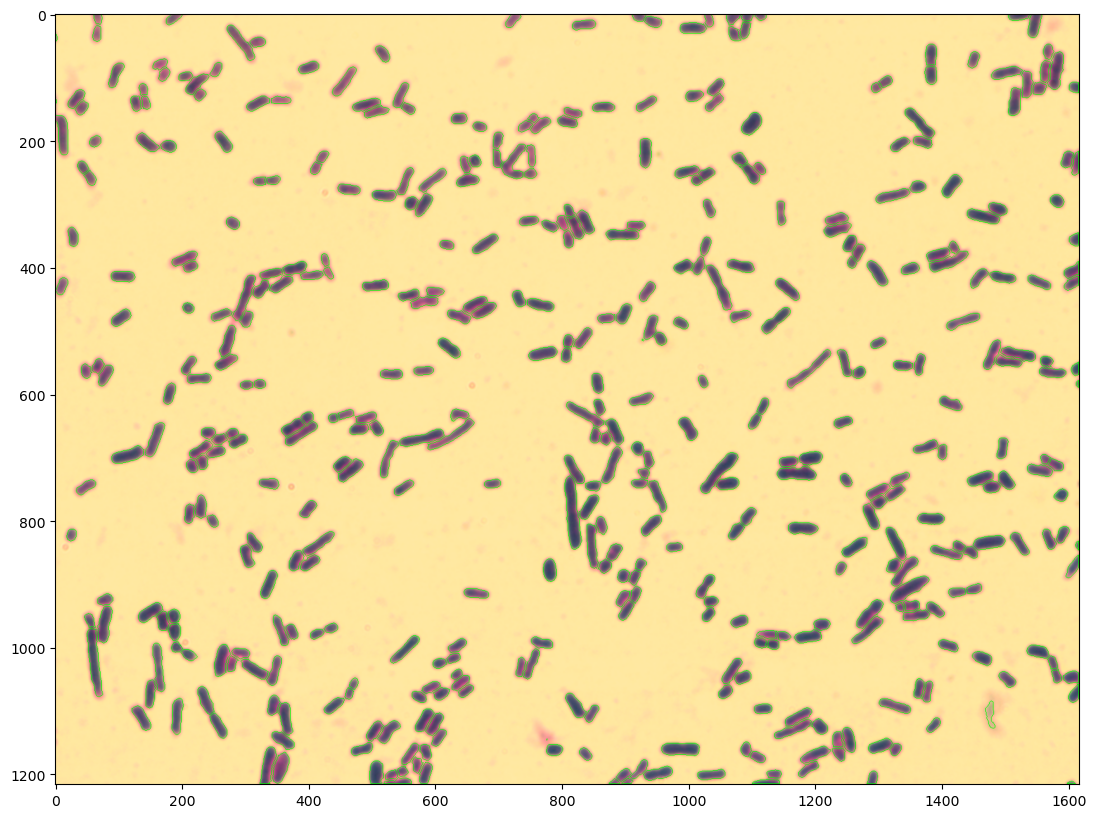

In [4]:
plt.figure(figsize=(14,10))
plt.imshow(test_image_class.segment_draw())
plt.show()

# Printing out info for classification

In [5]:
objects_features = test_image_class.all_object_features()

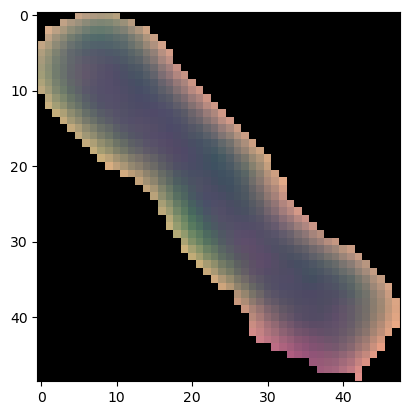

In [6]:
plt.imshow(objects_features['21']['masked_object'])
plt.show()

In [7]:
for key, value in objects_features['21'].items():
    if str(key) not in ['mask', 'masked_object']:
        print(f"{key}: {value}")

coords: {'x': 1341, 'y': 148, 'w': 48, 'h': 49}
color_props: {'red_peak': 85, 'green_peak': 77, 'blue_peak': 103, 'red_median': 103.0, 'green_median': 101.0, 'blue_median': 106.0}
region_props: {'perimeter': array([147.40916293]), 'area': array([923.]), 'axis_major_length': array([67.79054672]), 'axis_minor_length': array([18.07417008]), 'eccentricity': array([0.96380232]), 'orientation': array([0.75821725])}


# Constructing dataset

In [8]:
dataset = pd.DataFrame.from_dict([{'ID': key} | objects_features[key]['color_props'] | objects_features[key]['region_props']for key in objects_features], dtype=float)
dataset

,ID,red_peak,green_peak,blue_peak,red_median,green_median,blue_median,perimeter,area,axis_major_length,axis_minor_length,eccentricity,orientation
0,1.0,72.0,66.0,102.0,87.0,81.0,103.0,259.882251,2032.0,127.536389,21.001951,0.986348,0.093988
1,2.0,81.0,77.0,103.0,105.0,94.0,108.0,248.018290,1565.0,119.895397,17.234925,0.989614,0.116704
2,3.0,75.0,67.0,106.0,99.0,87.0,110.0,194.350288,1368.0,91.396109,20.300309,0.975021,-0.721159
3,4.0,70.0,65.0,112.0,108.0,82.0,114.0,169.580736,1279.0,73.255458,22.628413,0.951095,-1.026874
4,5.0,108.0,75.0,113.0,128.0,100.0,116.0,185.923882,1135.0,87.427692,17.627588,0.979463,0.422992
...,...,...,...,...,...,...,...,...,...,...,...,...,...
447,448.0,157.0,158.0,141.0,184.0,168.0,132.0,25.242641,41.0,12.815455,4.213197,0.944414,0.014037
448,449.0,179.0,156.0,136.0,198.0,164.5,138.5,14.414214,20.0,7.848567,3.322650,0.905969,0.000000
449,450.0,218.0,189.0,135.0,226.5,187.5,135.0,8.449747,10.0,4.603067,2.758945,0.800471,0.856347
450,451.0,188.0,122.0,129.0,188.5,134.5,123.5,8.242641,8.0,4.507894,2.104493,0.884338,0.953736


# Analysing dataset

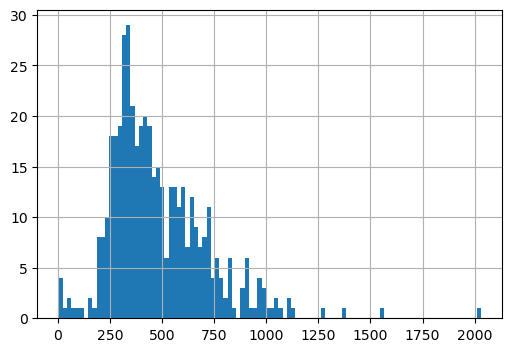

In [9]:
plt.figure(figsize=(6, 4))
plt.hist(dataset['area'], bins=100)
plt.grid()
plt.show()

In [10]:
pca = PCA(n_components=2)
pca.fit(dataset.drop(columns = 'ID').values)

PCA(n_components=2)

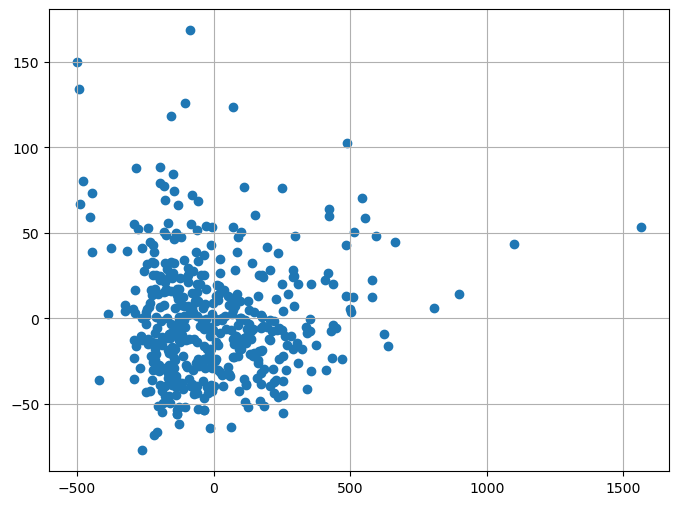

In [11]:
plt.figure(figsize=(8, 6))
plt.scatter(pca.transform(dataset.drop(columns = 'ID').values)[:,0], pca.transform(dataset.drop(columns = 'ID').values)[:,1])
plt.grid()
plt.show()

## checking PCA for different images

In [12]:
# fig, ax = plt.subplots(1,1, figsize=(12,10))
all_images_fobjects_dict = {}
all_images_fobjects_dataset = pd.DataFrame()
for i in [0, 1, 2, 4]:
    test_image_class = BF_image(verbose=False)
    test_image_class.load_image(image_paths[i])
    test_image_class.preprocess_image()
    test_image_class.segment_image(type='ridges')
    objects_features = test_image_class.all_object_features()
    test_image_dataset = pd.DataFrame.from_dict([objects_features[key]['color_props'] | objects_features[key]['region_props'] for key in objects_features], dtype=float)
    test_image_dataset['ID'] = [str(f'test_input_{i}_{key}') for key in objects_features]
    all_images_fobjects_dataset = pd.concat((all_images_fobjects_dataset, test_image_dataset))

In [13]:
all_pca = PCA(n_components=2)
all_pca.fit(all_images_fobjects_dataset.drop(columns = 'ID').values)

PCA(n_components=2)

In [14]:
plt.rcParams.update({'font.size': 16})

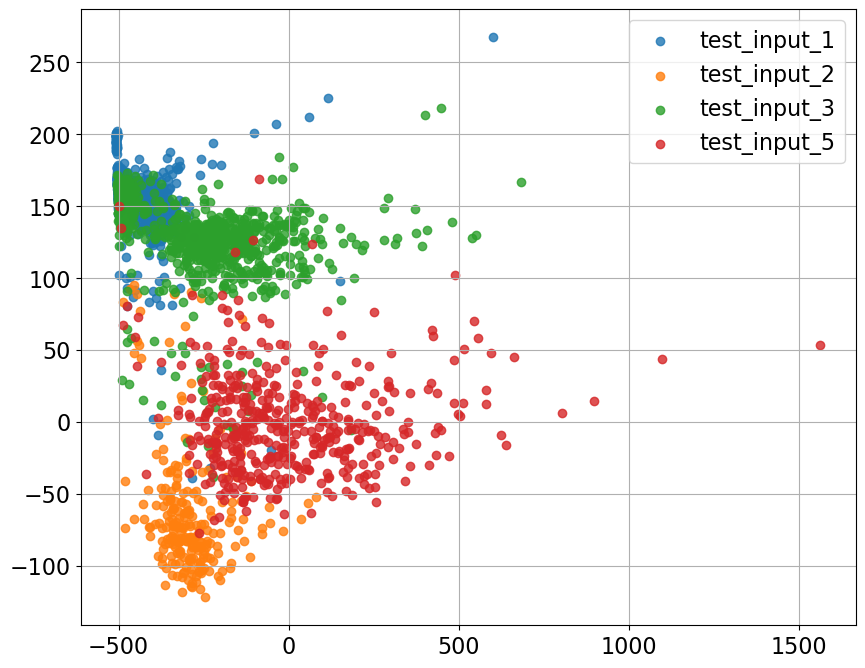

In [15]:
fig, ax = plt.subplots(1,1, figsize=(10,8))
for i in [0, 1, 2, 4]:
    test_image_class = BF_image(verbose=False)
    test_image_class.load_image(image_paths[i])
    test_image_class.preprocess_image()
    test_image_class.segment_image(type='ridges')
    objects_features = test_image_class.all_object_features()
    test_image_dataset = pd.DataFrame.from_dict([objects_features[key]['color_props'] | objects_features[key]['region_props'] for key in objects_features], dtype=float)
    
    ax.scatter(pca.transform(test_image_dataset.values)[:,0], pca.transform(test_image_dataset.values)[:,1], alpha=0.8, label=f"test_input_{i+1}")

ax.legend()
ax.grid()
plt.show()